# K-Means

K-means is an unsupervised machine learning algorithm used to group unlabeled data into a predefined number of clusters, 
KK, based on similarity.

- It works by initializing cluster centers, assigning each data point to the nearest center, recomputing each center as the mean of its assigned points, and repeating the process until the clusters stabilize.
- K-means is popular because it is simple and efficient for large datasets, but it works best when clusters are relatively compact and roughly spherical, and it requires the number of clusters to be chosen in advance.


In [36]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Add the libs directory to Python path
current_dir = Path.cwd()
libs_dir = os.path.join(current_dir, '..', 'libs')
libs_dir = os.path.abspath(libs_dir)
print("Libs directory:", libs_dir)
sys.path.insert(0, libs_dir)

from websocketclient import WebSocketCollector, SensorStream

dataset_dir = os.path.join(current_dir, '..', 'datasets')
models_dir = os.path.join(current_dir, '..', 'models')

ws_url = "ws://localhost:8000/ws"

Libs directory: /Users/kolithawarnakulasooriya/Projects/AI-driven-cyber-physical-system/libs


In [4]:
message_queue = WebSocketCollector(ws_url, max_messages=300).collect()
print("Collected messages:", message_queue.qsize())

WebSocket opened
WebSocket closed
Collected messages: 300


In [7]:
dataframe = SensorStream(message_queue=message_queue).get_as_dataframe()
dataframe = dataframe[['Temperature Sensor', 'Actual_Temperature Sensor']]
print(dataframe.head())

# save dataframe
dataframe.to_csv(os.path.join(dataset_dir, 'temperature_sensor_data.csv'), index=False)

  Temperature Sensor Actual_Temperature Sensor
0          63.245779                      74.2
1          78.966497                      74.2
2          69.787723                      74.2
3          69.432698                      74.2
4          80.239482                      74.2


In [15]:
df = pd.read_csv(os.path.join(dataset_dir, 'temperature_sensor_data.csv'))
df.head()

,Temperature Sensor,Actual_Temperature Sensor
0,63.245779,74.2
1,78.966497,74.2
2,69.787723,74.2
3,69.432698,74.2
4,80.239482,74.2


In [16]:
df.describe()

,Temperature Sensor,Actual_Temperature Sensor
count,279.000000,279.000000
mean,66.384639,67.224014
std,30.476334,29.945876
min,0.000000,7.700000
25%,50.922588,54.300000
50%,70.993821,72.500000
75%,94.158408,96.800000
max,100.000000,100.000000


In [ ]:
print(f"Is Nulls: {df.isnull().sum()}")
df = df.dropna(how='all')

Is Nulls: Temperature Sensor           19
Actual_Temperature Sensor    19
dtype: int64


In [19]:
print(f"Duplicates {df.duplicated().sum()}")
df = df.drop_duplicates()

Duplicates 40


In [22]:
X = np.array(df)
X = StandardScaler().fit_transform(X)

X[0:5]

array([[0.01388034, 0.3612415 ],
       [0.56617998, 0.3612415 ],
       [0.24371166, 0.3612415 ],
       [0.23123892, 0.3612415 ],
       [0.61090241, 0.3612415 ]])

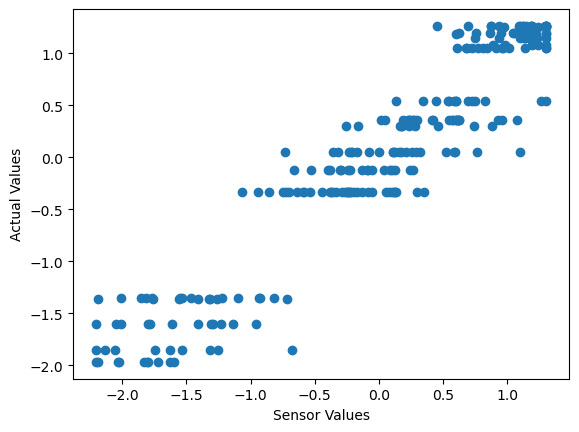

In [24]:
plt.Figure((10,6))

plt.scatter(X[:, 0], X[:, 1])

plt.xlabel("Sensor Values")
plt.ylabel("Actual Values")

plt.show()

In [26]:
cls = KMeans(n_clusters=3, random_state=42, n_init="auto")
cls.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 2)","[

In [27]:
cls.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 0, 2,
       2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
      dtype=int32)

In [28]:
cls.cluster_centers_

array([[-0.01011075, -0.01279777],
       [-1.58247747, -1.61946764],
       [ 0.99729378,  1.02377333]])

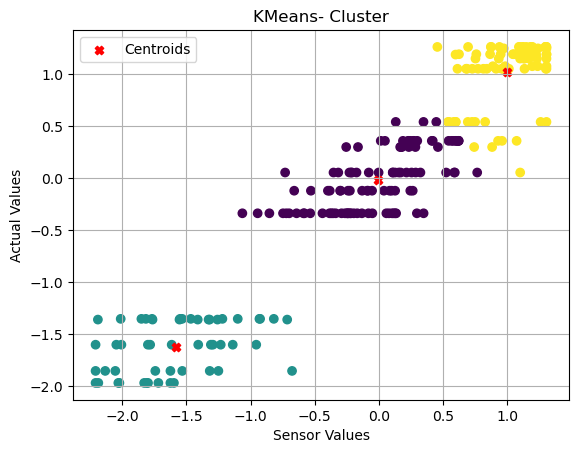

In [31]:
plt.Figure((10,6))

plt.scatter(X[:,0], X[:,1], c=cls.labels_)
plt.scatter(cls.cluster_centers_[:, 0], cls.cluster_centers_[:, 1], c='red', marker='X', label='Centroids')

plt.xlabel("Sensor Values")
plt.ylabel("Actual Values")
plt.title("KMeans- Cluster")
plt.grid(True)
plt.legend()
plt.show()

## Silhouette Score Clustering Evaluator

The Silhouette Score evaluates clustering models by assessing how well-matched each individual data point is to its assigned cluster versus neighboring clusters. It balances **cohesion** (how close a point is to its own cluster) and **separation** (how far a point is from the next nearest cluster).

### Understanding the Score

* **Range**: \([-1.0, 1.0]\)
* **1.0 (Ideal)**: Data points are far away from neighboring clusters and tightly packed within their own.
* **0.0 (Overlapping)**: Data points sit directly on the decision boundary between two neighboring clusters.
* **-1.0 (Misclassified)**: Data points have likely been assigned to the completely wrong cluster.


In [33]:
sil_euc = silhouette_score(X, cls.labels_, metric='euclidean')

inertia_euc = cls.inertia_

print("KMeans (Euclidean):")
print("Silhouette Score:", sil_euc)
print("Inertia (SSE):", inertia_euc)

KMeans (Euclidean):
Silhouette Score: 0.616037311842374
Inertia (SSE): 48.997424918724455


## Davies-Bouldin Index Clustering Evaluator

The Davies-Bouldin Index evaluates clustering models by calculating the similarity between each cluster and its most similar counterpart. It considers both **compactness** (how tight points are within a cluster) and **separation** (how far apart clusters are from each other). 

### Understanding the Score

* **Range**: \([0, \infty)\)
* **Optimal Score**: `0.0` represents perfectly compact, infinitely isolated clusters.
* **Rule of Thumb**: Lower scores indicate better defined, well-separated clusters. Higher scores mean clusters overlap heavily or suffer from massive inner variance.


In [37]:
dbi_score = davies_bouldin_score(X, cls.labels_)
print(f"Davies-Bouldin Index: {dbi_score:.4f}")

Davies-Bouldin Index: 0.4880


## Calinski-Harabasz Index Clustering Evaluator

The Calinski-Harabasz Index evaluates clustering quality by calculating the ratio of between-cluster dispersion to within-cluster dispersion. A higher score signifies that clusters are both highly compact internally and well-separated externally.

### Understanding the Score

* **Range**: \([0, \infty)\)
* **Optimal Score**: The highest peak on a cluster sweep curve represents the mathematically optimal cluster configuration.
* **Rule of Thumb**: Higher scores indicate better defined, more distinct, and tighter cluster separation.


In [40]:
ch = calinski_harabasz_score(X, cls.labels_)
print(f"Calinski-Harabasz Index: {ch:.4f}")

Calinski-Harabasz Index: 1033.1625
